In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ==================== 1. 数据读取与预处理 ====================
print("正在加载数据...")
df = pd.read_csv('C:/Users/1/Desktop/python量化/603993历史数据(2020-2025).csv')

# 数据预处理
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

def convert_volume(x):
    if isinstance(x, str):
        if 'M' in x: return float(x.replace('M', '')) * 1000000
        elif 'B' in x: return float(x.replace('B', '')) * 1000000000
    return float(x)

def convert_change(x):
    if isinstance(x, str): return float(x.replace('%', '')) / 100
    return float(x)

df['Volume'] = df['Volume'].apply(convert_volume)
df['Change'] = df['Change'].apply(convert_change)
for col in ['Close', 'Open', 'High', 'Low']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"数据加载完成: {len(df)}条记录, {df['datetime'].min().date()} 至 {df['datetime'].max().date()}")

正在加载数据...
数据加载完成: 1473条记录, 2020-01-20 至 2026-02-13


In [4]:
# ==================== 2. 马丁格尔策略类 ====================
class MartingaleStrategy:
    """马丁格尔策略 - 亏损后加倍下注，盈利后重置"""
    
    def __init__(self, initial_capital=100000, base_position=1000, 
                 max_multiplier=8, stop_loss_rate=0.5, take_profit_rate=0.05):
        self.initial_capital = initial_capital
        self.base_position = base_position
        self.max_multiplier = max_multiplier
        self.stop_loss_rate = stop_loss_rate
        self.take_profit_rate = take_profit_rate
        
    def backtest(self, df):
        capital = self.initial_capital
        current_multiplier = 1
        position = 0
        entry_price = 0
        records = []
        trades = []
        
        for i in range(len(df)):
            row = df.iloc[i]
            date = row['datetime']
            close = row['Close']
            
            # 计算持仓市值
            if position > 0:
                position_value = position * close
                unrealized_pnl = position * (close - entry_price)
            else:
                position_value = 0
                unrealized_pnl = 0
            
            total_value = capital + position_value
            
            # 止损检查
            if total_value < self.initial_capital * (1 - self.stop_loss_rate):
                if position > 0:
                    pnl = position * (close - entry_price)
                    capital += position * entry_price + pnl
                    trades.append({'date': date, 'type': 'STOP_LOSS', 'price': close,
                                  'position': position, 'pnl': pnl, 'multiplier': current_multiplier})
                    position = 0
                    current_multiplier = 1
                break
            
            # 交易逻辑
            if position == 0:
                # 开仓
                shares = self.base_position * current_multiplier
                cost = shares * close
                if cost <= capital:
                    position = shares
                    entry_price = close
                    capital -= cost
                    trades.append({'date': date, 'type': 'OPEN', 'price': close,
                                  'position': position, 'pnl': 0, 'multiplier': current_multiplier})
            else:
                pnl_pct = (close - entry_price) / entry_price
                
                if pnl_pct >= self.take_profit_rate:
                    # 止盈平仓
                    pnl = position * (close - entry_price)
                    capital += position * entry_price + pnl
                    trades.append({'date': date, 'type': 'TAKE_PROFIT', 'price': close,
                                  'position': position, 'pnl': pnl, 'multiplier': current_multiplier})
                    position = 0
                    current_multiplier = 1
                    
                elif pnl_pct < -0.05 and current_multiplier < self.max_multiplier:
                    # 亏损加仓（马丁格尔核心）
                    new_multiplier = current_multiplier * 2
                    additional_shares = self.base_position * current_multiplier
                    cost = additional_shares * close
                    
                    if cost <= capital:
                        total_cost = position * entry_price + additional_shares * close
                        position = position + additional_shares
                        entry_price = total_cost / position
                        capital -= cost
                        current_multiplier = new_multiplier
                        trades.append({'date': date, 'type': 'ADD', 'price': close,
                                      'position': additional_shares, 'pnl': 0, 'multiplier': current_multiplier})
            
            records.append({
                'date': date, 'close': close, 'capital': capital,
                'position': position, 'position_value': position_value,
                'total_value': total_value, 'unrealized_pnl': unrealized_pnl,
                'multiplier': current_multiplier
            })
        
        # 最终平仓
        if position > 0:
            final_close = df.iloc[-1]['Close']
            pnl = position * (final_close - entry_price)
            capital += position * entry_price + pnl
            trades.append({'date': df.iloc[-1]['datetime'], 'type': 'FINAL', 'price': final_close,
                          'position': position, 'pnl': pnl, 'multiplier': current_multiplier})
        
        return pd.DataFrame(records), pd.DataFrame(trades)

In [5]:
# ==================== 3. 执行回测 ====================
print("\n正在执行马丁格尔策略回测...")
strategy = MartingaleStrategy(
    initial_capital=100000,  # 初始资金10万
    base_position=1000,      # 基础仓位1000股
    max_multiplier=8,        # 最大8倍加仓
    stop_loss_rate=0.5,      # 50%止损线
    take_profit_rate=0.05    # 5%止盈
)

results, trades = strategy.backtest(df)


正在执行马丁格尔策略回测...


In [6]:
# ==================== 4. 计算绩效指标 ====================
initial = strategy.initial_capital
final = results.iloc[-1]['total_value']
total_return = (final / initial - 1) * 100

days = (results['date'].iloc[-1] - results['date'].iloc[0]).days
years = days / 365
annual_return = ((final / initial) ** (1/years) - 1) * 100

results['cummax'] = results['total_value'].cummax()
results['drawdown'] = (results['total_value'] - results['cummax']) / results['cummax']
max_drawdown = results['drawdown'].min() * 100

profit_trades = trades[trades['pnl'] > 0]
loss_trades = trades[trades['pnl'] < 0]
win_rate = len(profit_trades) / (len(profit_trades) + len(loss_trades)) * 100 if (len(profit_trades) + len(loss_trades)) > 0 else 0

In [7]:
# ==================== 5. 打印报告 ====================
print("\n" + "="*60)
print("马丁格尔策略回测报告")
print("="*60)
print(f"回测期间: {results['date'].iloc[0].strftime('%Y-%m-%d')} 至 {results['date'].iloc[-1].strftime('%Y-%m-%d')}")
print(f"交易天数: {len(results)}天 (约{years:.1f}年)")
print(f"\n【收益指标】")
print(f"初始资金: ¥{initial:,.2f}")
print(f"最终资金: ¥{final:,.2f}")
print(f"总收益率: {total_return:+.2f}%")
print(f"年化收益率: {annual_return:+.2f}%")
print(f"最大回撤: {max_drawdown:.2f}%")
print(f"\n【交易统计】")
print(f"总交易次数: {len(trades)}")
print(f"盈利次数: {len(profit_trades)}")
print(f"亏损次数: {len(loss_trades)}")
print(f"胜率: {win_rate:.1f}%")
print(f"总盈亏: ¥{trades['pnl'].sum():,.2f}")
if len(profit_trades) > 0:
    print(f"平均盈利: ¥{profit_trades['pnl'].mean():,.2f}")
if len(loss_trades) > 0:
    print(f"平均亏损: ¥{loss_trades['pnl'].mean():,.2f}")
print("="*60)


马丁格尔策略回测报告
回测期间: 2020-01-20 至 2026-02-13
交易天数: 1473天 (约6.1年)

【收益指标】
初始资金: ¥100,000.00
最终资金: ¥178,630.00
总收益率: +78.63%
年化收益率: +10.03%
最大回撤: -22.15%

【交易统计】
总交易次数: 122
盈利次数: 39
亏损次数: 1
胜率: 97.5%
总盈亏: ¥78,630.00
平均盈利: ¥2,231.03
平均亏损: ¥-8,380.00


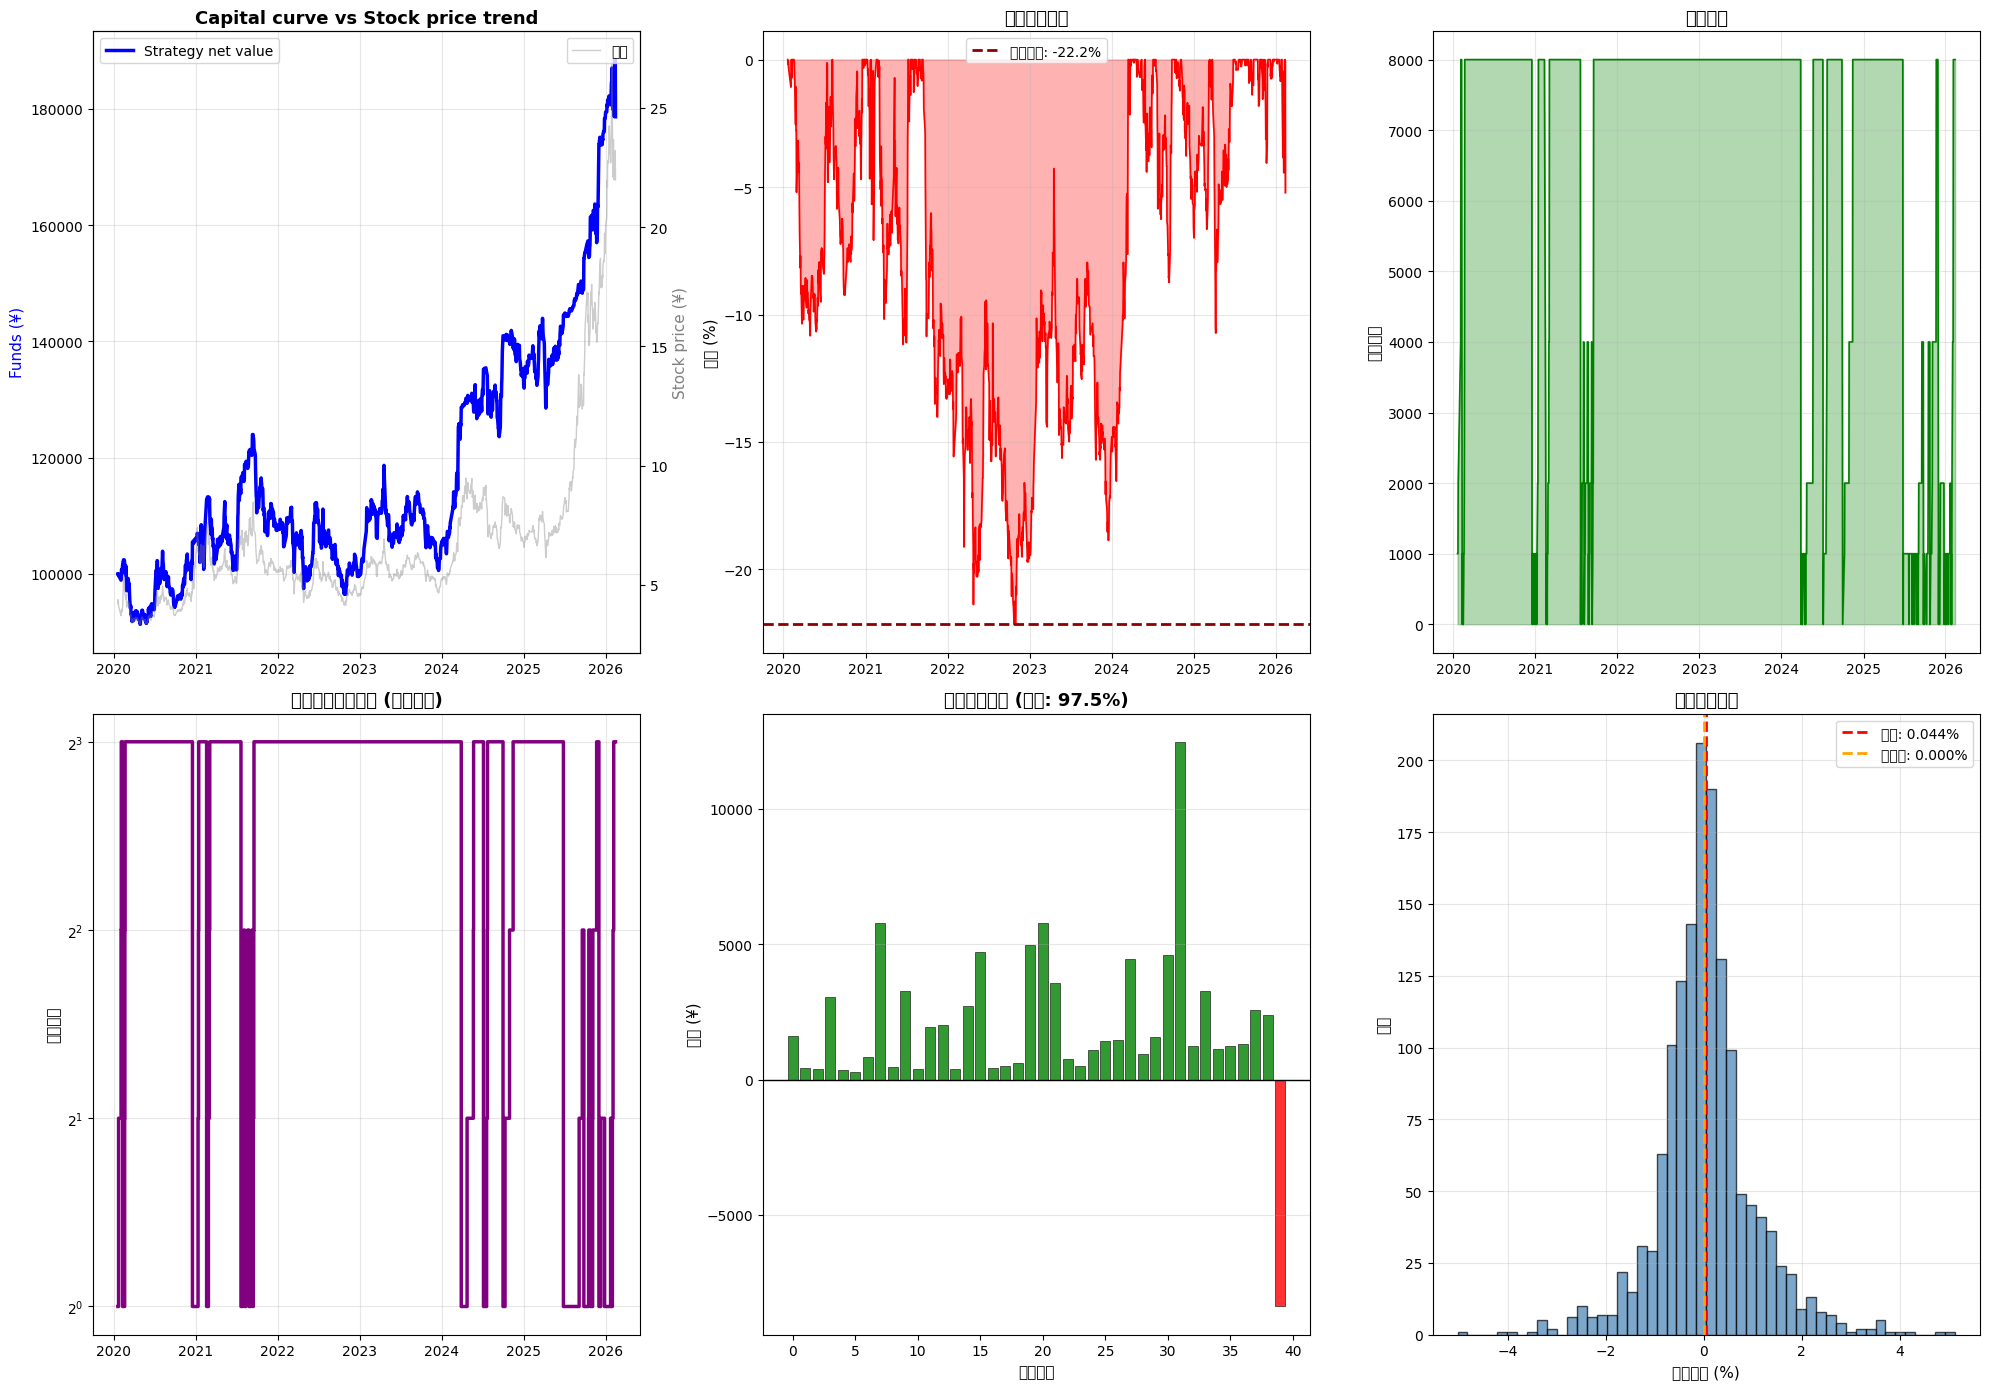


✅ 分析图表已保存至: C:/Users/1/Desktop/python量化/martingale_strategy_analysis.png


In [ ]:
# ==================== 6. 绘制分析图表 ====================
fig = plt.figure(figsize=(20, 14))

# 1. 资金曲线与股价对比
ax1 = fig.add_subplot(2, 3, 1)
ax1_twin = ax1.twinx()
ax1.plot(results['date'], results['total_value'], 'b-', linewidth=2.5, label='策略净值')
ax1_twin.plot(results['date'], results['close'], 'gray', alpha=0.4, linewidth=1, label='股价')
ax1.set_ylabel('资金 (¥)', color='b', fontsize=11)
ax1_twin.set_ylabel('股价 (¥)', color='gray', fontsize=11)
ax1.set_title('资金曲线 vs 股价走势', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1_twin.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. 回撤曲线
ax2 = fig.add_subplot(2, 3, 2)
ax2.fill_between(results['date'], results['drawdown'] * 100, 0, color='red', alpha=0.3)
ax2.plot(results['date'], results['drawdown'] * 100, 'r-', linewidth=1.2)
ax2.axhline(y=max_drawdown, color='darkred', linestyle='--', linewidth=2, label=f'最大回撤: {max_drawdown:.1f}%')
ax2.set_ylabel('回撤 (%)', fontsize=11)
ax2.set_title('资金回撤分析', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. 持仓变化
ax3 = fig.add_subplot(2, 3, 3)
ax3.fill_between(results['date'], results['position'], 0, color='green', alpha=0.3)
ax3.plot(results['date'], results['position'], 'g-', linewidth=1.2)
ax3.set_ylabel('持仓股数', fontsize=11)
ax3.set_title('持仓变化', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. 马丁格尔倍数
ax4 = fig.add_subplot(2, 3, 4)
ax4.step(results['date'], results['multiplier'], where='post', color='purple', linewidth=2.5)
ax4.set_ylabel('仓位倍数', fontsize=11)
ax4.set_title('马丁格尔倍数变化 (对数刻度)', fontsize=13, fontweight='bold')
ax4.set_yscale('log', base=2)
ax4.grid(True, alpha=0.3)

# 5. 交易盈亏分布
ax5 = fig.add_subplot(2, 3, 5)
trades_pnl = trades[trades['pnl'] != 0]
if len(trades_pnl) > 0:
    colors = ['green' if x > 0 else 'red' for x in trades_pnl['pnl']]
    bars = ax5.bar(range(len(trades_pnl)), trades_pnl['pnl'], color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax5.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax5.set_xlabel('交易序号', fontsize=11)
ax5.set_ylabel('盈亏 (¥)', fontsize=11)
ax5.set_title(f'交易盈亏分布 (胜率: {win_rate:.1f}%)', fontsize=13, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')

# 6. 日收益率分布
ax6 = fig.add_subplot(2, 3, 6)
results['daily_return'] = results['total_value'].pct_change() * 100
returns_clean = results['daily_return'].dropna()
ax6.hist(returns_clean, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax6.axvline(x=returns_clean.mean(), color='red', linestyle='--', linewidth=2, label=f'均值: {returns_clean.mean():.3f}%')
ax6.axvline(x=returns_clean.median(), color='orange', linestyle='--', linewidth=2, label=f'中位数: {returns_clean.median():.3f}%')
ax6.set_xlabel('日收益率 (%)', fontsize=11)
ax6.set_ylabel('频次', fontsize=11)
ax6.set_title('日收益率分布', fontsize=13, fontweight='bold')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('C:/Users/1/Desktop/python量化/martingale_strategy_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✅ 分析图表已保存至: C:/Users/1/Desktop/python量化/martingale_strategy_analysis.png")

In [8]:
# ==================== 7. 打印详细交易记录 ====================
print("\n" + "="*80)
print("详细交易记录")
print("="*80)
print(f"{'日期':<12} {'类型':<12} {'价格':<8} {'股数':<10} {'盈亏':<12} {'倍数'}")
print("-"*80)

for idx, trade in trades.iterrows():
    date_str = trade['date'].strftime('%Y-%m-%d') if hasattr(trade['date'], 'strftime') else str(trade['date'])[:10]
    pnl_str = f"¥{trade['pnl']:,.2f}" if trade['pnl'] != 0 else "-"
    print(f"{date_str:<12} {trade['type']:<12} ¥{trade['price']:<7.2f} {trade['position']:<10.0f} {pnl_str:<12} {trade['multiplier']}x")

print("="*80)


详细交易记录
日期           类型           价格       股数         盈亏           倍数
--------------------------------------------------------------------------------
2020-01-20   OPEN         ¥4.38    1000       -            1x
2020-01-23   ADD          ¥4.12    1000       -            2x
2020-02-03   ADD          ¥3.71    2000       -            4x
2020-02-04   ADD          ¥3.78    4000       -            8x
2020-02-10   TAKE_PROFIT  ¥4.08    8000       ¥1,600.00    8x
2020-02-11   OPEN         ¥4.28    1000       -            1x
2020-02-12   TAKE_PROFIT  ¥4.71    1000       ¥430.00      1x
2020-02-13   OPEN         ¥5.02    1000       -            1x
2020-02-14   TAKE_PROFIT  ¥5.42    1000       ¥400.00      1x
2020-02-17   OPEN         ¥5.40    1000       -            1x
2020-02-19   ADD          ¥4.73    1000       -            2x
2020-02-20   ADD          ¥4.68    2000       -            4x
2020-02-21   ADD          ¥4.60    4000       -            8x
2020-12-17   TAKE_PROFIT  ¥5.12    8000    